<a href="https://colab.research.google.com/github/heisenberg304/aprendiendo-ml-cloud/blob/semana-5/dia3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_10757/1235584663.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/tmp/ipykernel_10757/1235584663.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

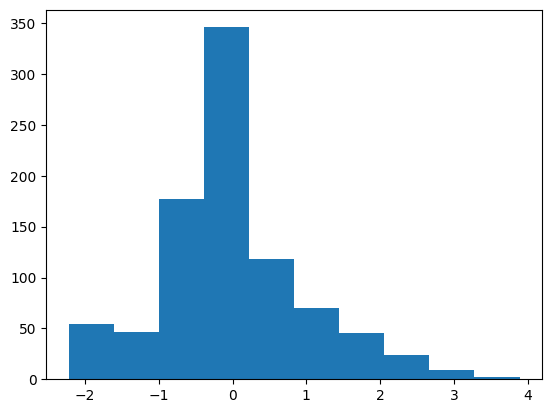

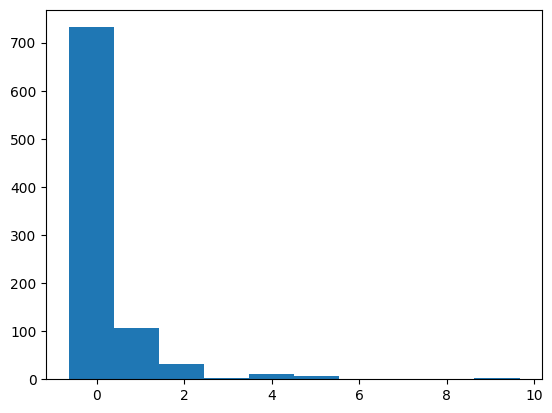

In [8]:
#librerias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


#importar dataset
data = pd.read_csv("/content/drive/MyDrive/data_csv/titanic.csv")

#limpieza de datos
data["Age"].fillna(data["Age"].median(), inplace=True)
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)
data = data.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1)

#Transformaciones
data["Is_female"] = data["Sex"].map({"male": 0, "female":1})
data = data.drop("Sex", axis=1)

data["Relatives"] = data["SibSp"] + data["Parch"]
#Encoding
embarked = pd.get_dummies(data["Embarked"])
data = data.drop("Embarked", axis=1)
#unir al dataset
data = pd.concat([data, embarked], axis=1)

#escalar
scaler = StandardScaler()
#crea x
x1 = data[["Age"]]
x2 = data[["Fare"]]
x3 = data[["Age", "Fare"]]

#escalar datos
x1_scaled = scaler.fit_transform(x1)
x2_scaled = scaler.fit_transform(x2)
x3_scaled = scaler.fit_transform(x3)


#graficar
#Age por separado
plt.hist(data["Age"])
plt.show()
plt.hist(x1_scaled)
plt.show()
#Fare por separado
plt.hist(data["Fare"])
plt.show()
plt.hist(x2_scaled)
plt.show()
#Age y Fare juntos
plt.hist([data["Age"], data["Fare"]])
plt.show()
plt.hist(x3_scaled)
plt.show()


In [16]:
#librerias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

#importar dataset
data = pd.read_csv("/content/drive/MyDrive/data_csv/titanic.csv")

#limpieza de datos
data["Age"].fillna(data["Age"].median(), inplace=True)
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)
data = data.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1)

#Transformaciones
data["Is_female"] = data["Sex"].map({"male": 0, "female":1})
data = data.drop("Sex", axis=1)

data["Relatives"] = data["SibSp"] + data["Parch"]
#Encoding
embarked = pd.get_dummies(data["Embarked"])
data = data.drop("Embarked", axis=1)
#unir al dataset
data = pd.concat([data, embarked], axis=1)


#escalar
scaler = StandardScaler()
#escalar datos
x1 = data[["Age"]]
x2 = data[["Fare"]]

data["Age"] = scaler.fit_transform(x1)
data["Fare"] = scaler.fit_transform(x2)


#crea x,y
x = data[["Pclass",	"Age",	"SibSp",	"Parch",	"Fare",	"Is_female",	"Relatives",	"C",	"Q",	"S"]]
y = data["Survived"]
#distribuir dataset
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state= 42
)
#crear modelo
model = LogisticRegression()
#entrenar modelo
model.fit(x_train, y_train)

#prediccion
pred = model.predict(x_test)

#metricas
matrix = confusion_matrix(y_test, pred)
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(pred)
print(y_test)
print(f"matrix -> {matrix}")
print(f"accuracy -> {accuracy}")
print(f"precision -> {precision}")
print(f"recall -> {recall}")
print(f"f1 score -> {f1}")

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]
709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64
matrix -> [[90 15]
 [19 55]]
accuracy -> 0.8100558659217877
precision -> 0.7857142857142857
recall -> 0.7432432432432432
f1 score -> 0.7638888888888888


/tmp/ipykernel_10757/1428367861.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/tmp/ipykernel_10757/1428367861.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr